# Downstream Classification from BYOL Embeddings

Evaluates how well the learned 256-dim projection embeddings support supervised classification.
Three classifiers are compared: **KNN**, **Random Forest**, and a **PyTorch MLP**.
No images are needed — classifiers train directly on the pre-extracted `.npy` feature files.

## 1. Setup

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, f1_score, make_scorer,
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

### 1.1 Configuration

Edit the three variables below before running the notebook.

In [ ]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
run_name  = "run_20260331_1652_efficient_wclosest_p0.5"
LABEL_SET = "all"    # "base" | "morphology" | "all"
SEED      = 42
# ─────────────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 2. Load Data

Reads the pre-extracted train and test projections saved by `create_embeddings.py`.
The splits are identical to those used during BYOL training (same seed).

In [67]:
project_location = Path("..").resolve()
emb_dir = project_location / "outputs" / run_name / "embeddings"

X_train = np.load(emb_dir / "train_projections.npy").astype(np.float32)
y_train = np.load(emb_dir / "train_labels.npy").astype(np.int64)
X_test  = np.load(emb_dir / "test_projections.npy").astype(np.float32)
y_test  = np.load(emb_dir / "test_labels.npy").astype(np.int64)

print(f"Train embeddings : {X_train.shape}")
print(f"Train labels     : {y_train.shape}")
print(f"Test  embeddings : {X_test.shape}")
print(f"Test  labels     : {y_test.shape}")

FileNotFoundError: [Errno 2] No such file or directory: '/home/markusbredberg/Scripts/p3_suplat/outputs/run_20260331_1659_efficient_wclosest_p0.5/embeddings/train_projections.npy'

### 2.1 Feature normalisation

`StandardScaler` is fit on the training embeddings only and applied to both splits. Essential for KNN (distance-based) and Logistic Regression. RF is scale-invariant; the MLP uses BatchNorm internally.

In [ ]:
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'Train mean (first 3 dims): {X_train_s.mean(axis=0)[:3].round(4)}')
print(f'Train std  (first 3 dims): {X_train_s.std(axis=0)[:3].round(4)}')

### 2.2 Label subset selection

| `LABEL_SET` | Columns | Classes |
|---|---|---|
| `"base"` | 0–2 | FRI, FRII, Hybrids |
| `"morphology"` | 5–14 | C-curv … Restarted |
| `"all"` | 0–19 | All 20 classes |

In [ ]:
ALL_CLASS_NAMES = [
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    'C-curv', 'S-curv', 'Misalign', 'Wings', 'X-shaped',
    'Straight jets', 'Multi hotspots', 'Cont. jets', 'Banding',
    'One-sided', 'Restarted', 'Cluster', 'Merger', 'Diffuse', 'Unknown',
]

LABEL_SETS = {
    "base":       list(range(0, 3)),
    "morphology": list(range(5, 15)),
    "all":        list(range(0, 20)),
}

label_cols  = LABEL_SETS[LABEL_SET]
class_names = [ALL_CLASS_NAMES[i] for i in label_cols]
n_classes   = len(class_names)

y_train_sub = y_train[:, label_cols]
y_test_sub  = y_test[:, label_cols]

print(f"Label set  : {LABEL_SET}")
print(f"n_classes  : {n_classes}")
print(f"Classes    : {class_names}")

Label set  : base
n_classes  : 3
Classes    : ['FRI', 'FRII', 'Hybrids']


### 2.3 Class distribution

Positive sample count per class in train and test.

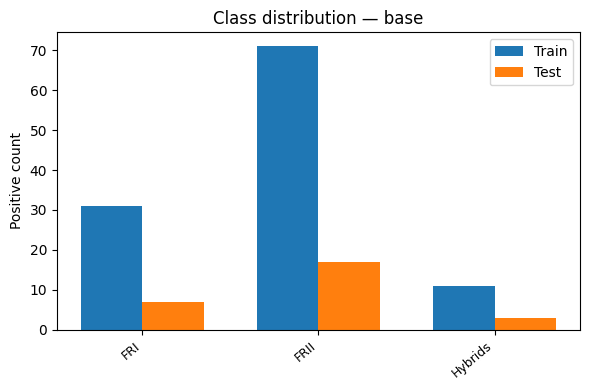

In [ ]:
train_counts = y_train_sub.sum(axis=0)
test_counts  = y_test_sub.sum(axis=0)

x = np.arange(n_classes)
width = 0.35
fig, ax = plt.subplots(figsize=(max(6, n_classes * 0.9), 4))
ax.bar(x - width/2, train_counts, width, label='Train')
ax.bar(x + width/2, test_counts,  width, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Positive count')
ax.set_title(f'Class distribution — {LABEL_SET}')
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Evaluation helpers

Shared functions used by all classifiers.

In [ ]:
def evaluate(y_true, y_pred, y_prob, name, class_names):
    """Print classification report, plot confusion matrices, compute ROC-AUC."""
    n = len(class_names)
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names,
                                zero_division=0))

    # ── Accuracy and AUC summary ──────────────────────────────────────────
    from sklearn.metrics import accuracy_score
    accuracy = accuracy_score(y_true.reshape(-1), y_pred.reshape(-1))
    per_class_acc = [(y_true[:, i] == y_pred[:, i]).mean() for i in range(n)]
    aucs = []
    for i in range(n):
        if len(np.unique(y_true[:, i])) < 2:
            aucs.append(float('nan'))
        else:
            aucs.append(roc_auc_score(y_true[:, i], y_prob[:, i]))
    macro_auc = np.nanmean(aucs)

    print(f"{'Accuracy (all labels):':<30} {accuracy:.4f}")
    print(f"{'Macro ROC-AUC:':<30} {macro_auc:.4f}")
    print()
    print(f"  {'Class':<22} {'Accuracy':>10} {'ROC-AUC':>10}")
    print(f"  {'-'*44}")
    for cname, acc, auc in zip(class_names, per_class_acc, aucs):
        auc_str = f"{auc:.4f}" if not np.isnan(auc) else "   n/a"
        print(f"  {cname:<22} {acc:>10.4f} {auc_str:>10}")

    # ── Confusion matrices ────────────────────────────────────────────────
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))
    axes = np.array(axes).reshape(-1)
    for i, (cname, acc) in enumerate(zip(class_names, per_class_acc)):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        disp = ConfusionMatrixDisplay(cm, display_labels=['Neg', 'Pos'])
        disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
        axes[i].set_title(f"{cname}  (acc={acc:.3f})", fontsize=9)
    for j in range(n, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{name} — Confusion matrices', fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── ROC-AUC bar chart ─────────────────────────────────────────────────
    fig_w = max(8, n * 0.9)
    fig_h = 3.5 + max(0, (n - 10) * 0.1)   # extra height for rotated labels
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    colors = ['steelblue' if not np.isnan(a) else 'lightgrey' for a in aucs]
    ax.bar(range(n), aucs, color=colors)
    ax.set_xticks(range(n))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='random')
    ax.axhline(macro_auc, color='green', linestyle='--', linewidth=1,
               label=f'macro avg = {macro_auc:.3f}')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('ROC-AUC')
    ax.set_title(f'{name} — ROC-AUC per class')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return {
        'f1_per_class':  f1_score(y_true, y_pred, average=None, zero_division=0),
        'f1_macro':      f1_score(y_true, y_pred, average='macro', zero_division=0),
        'auc_per_class': np.array(aucs),
        'auc_macro':     macro_auc,
        'accuracy':      accuracy,
    }


## 3. Dummy Baseline

Predicts each label by sampling from the training label distribution independently. Sets the performance floor — every real classifier should beat this.

In [ ]:
dummy_base = DummyClassifier(strategy='stratified', random_state=SEED)
dummy      = MultiOutputClassifier(dummy_base)
dummy.fit(X_train_s, y_train_sub)
print('Dummy classifier fitted.')

In [ ]:
y_pred_dummy = dummy.predict(X_test_s)
y_prob_dummy = y_pred_dummy.astype(float)  # 0/1 as probability proxy
results_dummy = evaluate(y_test_sub, y_pred_dummy, y_prob_dummy,
                         'Dummy (stratified)', class_names)

## 4. KNN Classifier

k-Nearest Neighbours in the 256-dim scaled embedding space. Each label is treated as an independent binary classification problem via `MultiOutputClassifier`.

In [ ]:
knn_base = KNeighborsClassifier(n_neighbors=15, metric='euclidean', n_jobs=-1)
knn      = MultiOutputClassifier(knn_base)
knn.fit(X_train_s, y_train_sub)
print('KNN fitted.')

KNN fitted.



  KNN
              precision    recall  f1-score   support

         FRI       0.00      0.00      0.00         7
        FRII       0.55      0.94      0.70        17
     Hybrids       0.00      0.00      0.00         3

   micro avg       0.53      0.59      0.56        27
   macro avg       0.18      0.31      0.23        27
weighted avg       0.35      0.59      0.44        27
 samples avg       0.53      0.53      0.53        27



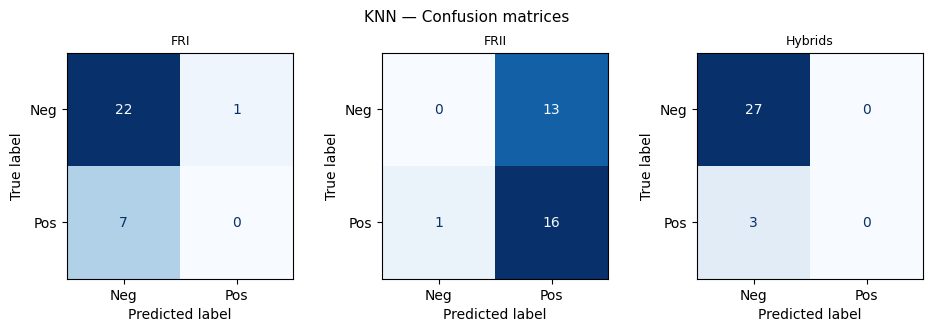

/tmp/ipykernel_45247/910970329.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=40, ha='right', fontsize=9)


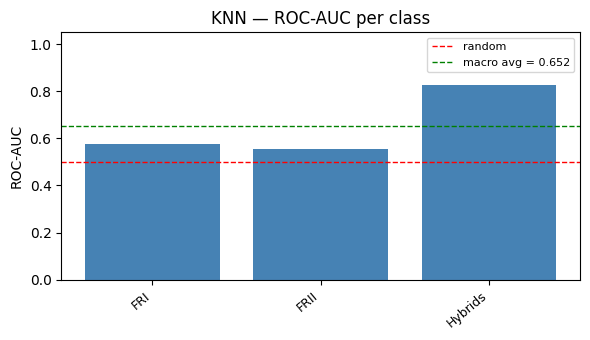

In [ ]:
y_pred_knn = knn.predict(X_test_s)
y_prob_knn = np.stack(
    [est.predict_proba(X_test_s)[:, 1] for est in knn.estimators_], axis=1
)
results_knn = evaluate(y_test_sub, y_pred_knn, y_prob_knn, 'KNN', class_names)

In [ ]:
scorer = make_scorer(f1_score, average='macro', zero_division=0)
cv_scores_knn = cross_val_score(
    MultiOutputClassifier(KNeighborsClassifier(n_neighbors=15,
                                               metric='euclidean', n_jobs=-1)),
    X_train_s, y_train_sub, cv=5, scoring=scorer, n_jobs=-1
)
print(f'KNN  5-fold CV macro-F1: {cv_scores_knn.mean():.4f} ± {cv_scores_knn.std():.4f}')

## 5. Random Forest Classifier

200-tree Random Forest. `MultiOutputClassifier` wraps it for multi-label output.

In [ ]:
rf_base = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf      = MultiOutputClassifier(rf_base)
rf.fit(X_train_s, y_train_sub)
print('Random Forest fitted.')

Random Forest fitted.



  Random Forest
              precision    recall  f1-score   support

         FRI       0.00      0.00      0.00         7
        FRII       0.70      0.82      0.76        17
     Hybrids       1.00      0.33      0.50         3

   micro avg       0.71      0.56      0.62        27
   macro avg       0.57      0.39      0.42        27
weighted avg       0.55      0.56      0.53        27
 samples avg       0.50      0.50      0.50        27



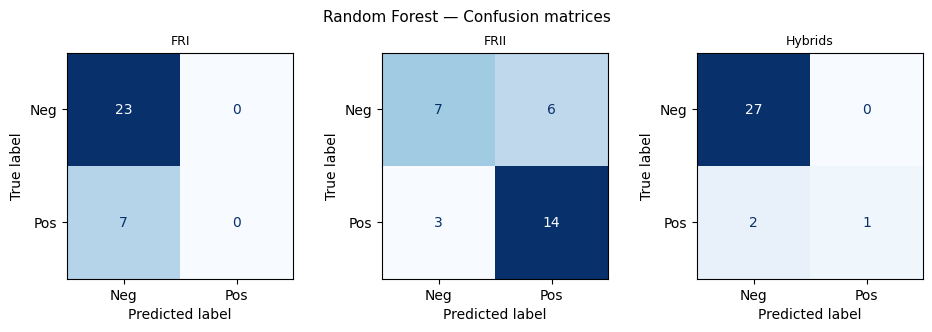

/tmp/ipykernel_45247/910970329.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=40, ha='right', fontsize=9)


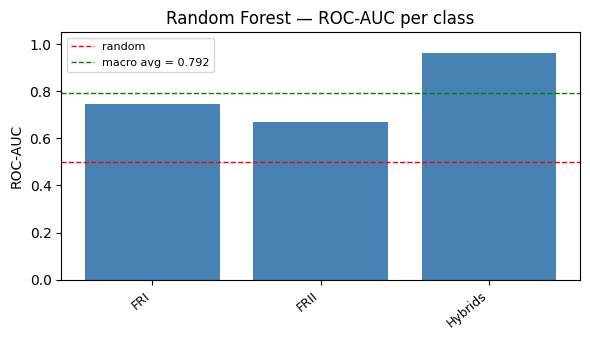

In [ ]:
y_pred_rf = rf.predict(X_test_s)
y_prob_rf = np.stack(
    [est.predict_proba(X_test_s)[:, 1] for est in rf.estimators_], axis=1
)
results_rf = evaluate(y_test_sub, y_pred_rf, y_prob_rf, 'Random Forest', class_names)

In [ ]:
cv_scores_rf = cross_val_score(
    MultiOutputClassifier(RandomForestClassifier(n_estimators=200,
                                                 random_state=SEED, n_jobs=-1)),
    X_train_s, y_train_sub, cv=5, scoring=scorer, n_jobs=-1
)
print(f'RF   5-fold CV macro-F1: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

## 6. Logistic Regression

A linear probe on the scaled embeddings — the standard way to test whether the BYOL embedding space is already linearly separable. If LR performance is close to RF/MLP, the nonlinear classifiers add little beyond what the encoder already provides.

In [ ]:
lr_base = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
lr      = MultiOutputClassifier(lr_base)
lr.fit(X_train_s, y_train_sub)
print('Logistic Regression fitted.')

In [ ]:
y_pred_lr = lr.predict(X_test_s)
y_prob_lr = np.stack(
    [est.predict_proba(X_test_s)[:, 1] for est in lr.estimators_], axis=1
)
results_lr = evaluate(y_test_sub, y_pred_lr, y_prob_lr,
                      'Logistic Regression', class_names)

In [ ]:
cv_scores_lr = cross_val_score(
    MultiOutputClassifier(LogisticRegression(max_iter=1000,
                                             random_state=SEED, n_jobs=-1)),
    X_train_s, y_train_sub, cv=5, scoring=scorer, n_jobs=-1
)
print(f'LR   5-fold CV macro-F1: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')

## 7. MLP Classifier (PyTorch)

Two-hidden-layer MLP. For each source the head outputs `(n_classes, 2)` logits — one logit pair per class. Row-wise softmax gives the probability of belonging to that class. Loss is cross-entropy summed over all `N × n_classes` binary decisions.

In [ ]:
class MultiLabelMLP(nn.Module):
    def __init__(self, in_dim: int, n_classes: int,
                 hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.encoder   = nn.Sequential(*layers)
        self.head      = nn.Linear(prev, n_classes * 2)
        self.n_classes = n_classes

    def forward(self, x):
        return self.head(self.encoder(x)).view(-1, self.n_classes, 2)

mlp = MultiLabelMLP(in_dim=X_train_s.shape[1], n_classes=n_classes).to(device)

# ── Parameter summary ────────────────────────────────────────────────────────
print(f"{'Layer':<35} {'Shape':>20} {'Params':>10}")
print('-' * 67)
total = 0
for name, param in mlp.named_parameters():
    n = param.numel()
    total += n
    print(f"{name:<35} {str(tuple(param.shape)):>20} {n:>10,}")
print('-' * 67)
print(f"{'Total':<35} {'':>20} {total:>10,}")


In [ ]:
# ── Hyper-parameters ─────────────────────────────────────────────────────────
N_EPOCHS          = 100
BATCH_SIZE        = 256
LR                = 1e-3
WEIGHT_DECAY      = 1e-4   # L2 regularisation
VAL_FRAC          = 0.15
PATIENCE          = 15     # early stopping: stop if val loss doesn't improve
# ─────────────────────────────────────────────────────────────────────────────

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

# ── Train / val split ────────────────────────────────────────────────────────
n_val         = int(len(X_train_s) * VAL_FRAC)
val_idx_mlp   = rng.choice(len(X_train_s), size=n_val, replace=False)
train_idx_mlp = np.setdiff1d(np.arange(len(X_train_s)), val_idx_mlp)

X_tr_t  = torch.from_numpy(X_train_s[train_idx_mlp])
y_tr_t  = torch.from_numpy(y_train_sub[train_idx_mlp].astype(np.int64))
X_val_t = torch.from_numpy(X_train_s[val_idx_mlp])
y_val_t = torch.from_numpy(y_train_sub[val_idx_mlp].astype(np.int64))

train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                      batch_size=BATCH_SIZE, shuffle=True)

# ── Class weights: upweight rare positive classes ────────────────────────────
# For each class: weight_pos = n_neg / n_pos  (clipped to avoid explosion)
pos_counts  = y_tr_t.float().sum(dim=0).clamp(min=1)
neg_counts  = len(y_tr_t) - pos_counts
pos_weights = (neg_counts / pos_counts).clamp(max=20).to(device)  # (n_classes,)

# ── Optimiser + LR scheduler ─────────────────────────────────────────────────
optimiser = torch.optim.Adam(mlp.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=5, verbose=True
)

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val_loss  = float('inf')
best_state     = None
epochs_no_impr = 0

for epoch in range(1, N_EPOCHS + 1):
    # Train
    mlp.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = mlp(xb)                              # (B, n_classes, 2)
        # Weighted cross-entropy: repeat pos_weights for each sample
        loss = sum(
            F.cross_entropy(logits[:, c, :], yb[:, c],
                            weight=torch.tensor([1.0, pos_weights[c].item()],
                                                device=device))
            for c in range(n_classes)
        ) / n_classes
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item() * len(xb)
    train_losses.append(epoch_loss / len(X_tr_t))

    # Validate
    mlp.eval()
    with torch.no_grad():
        val_logits = mlp(X_val_t.to(device))
        val_loss = sum(
            F.cross_entropy(val_logits[:, c, :], y_val_t[:, c].to(device),
                            weight=torch.tensor([1.0, pos_weights[c].item()],
                                                device=device))
            for c in range(n_classes)
        ).item() / n_classes
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_state     = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
        epochs_no_impr = 0
    else:
        epochs_no_impr += 1
        if epochs_no_impr >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train={train_losses[-1]:.4f}  "
              f"val={val_losses[-1]:.4f}  lr={optimiser.param_groups[0]['lr']:.2e}")

# Restore best weights
mlp.load_state_dict(best_state)
print(f"\nRestored best model (val loss = {best_val_loss:.4f})")

# Plot
plt.figure(figsize=(6, 3))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
best_ep = int(np.argmin(val_losses))
plt.axvline(best_ep, color='grey', linestyle='--', linewidth=1,
            label=f'Best epoch ({best_ep + 1})')
plt.xlabel('Epoch')
plt.ylabel('Weighted cross-entropy loss')
plt.title('MLP training curve')
plt.legend()
plt.tight_layout()
plt.show()



  MLP (PyTorch)
              precision    recall  f1-score   support

         FRI       0.00      0.00      0.00         7
        FRII       0.59      1.00      0.74        17
     Hybrids       0.00      0.00      0.00         3

   micro avg       0.59      0.63      0.61        27
   macro avg       0.20      0.33      0.25        27
weighted avg       0.37      0.63      0.47        27
 samples avg       0.57      0.57      0.57        27



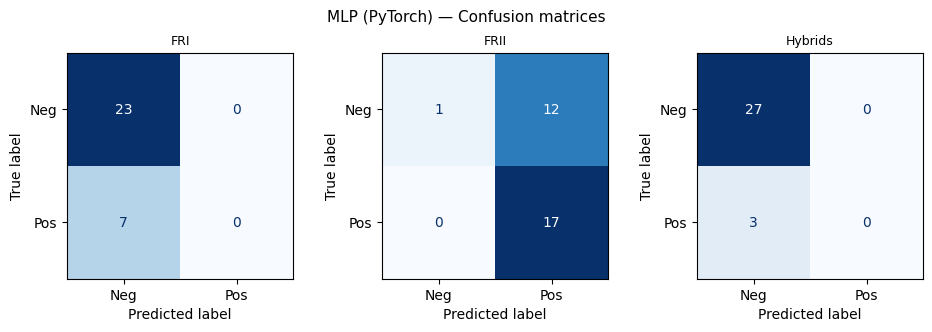

/tmp/ipykernel_45247/910970329.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=40, ha='right', fontsize=9)


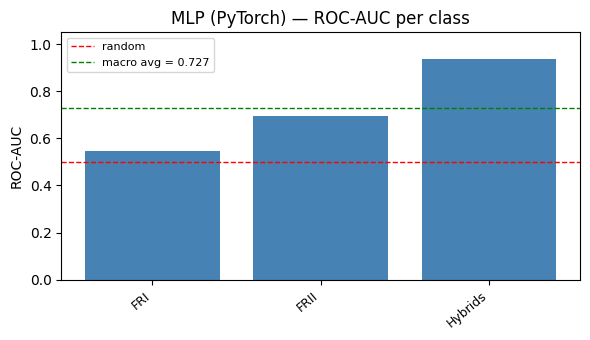

In [ ]:
mlp.eval()
with torch.no_grad():
    logits_test = mlp(torch.from_numpy(X_test_s).to(device))  # (N, n_classes, 2)
    probs_test  = F.softmax(logits_test, dim=-1)             # (N, n_classes, 2)

y_prob_mlp = probs_test[:, :, 1].cpu().numpy()              # P(positive) per class
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

results_mlp = evaluate(y_test_sub, y_pred_mlp, y_prob_mlp,
                       "MLP (PyTorch)", class_names)

## 8. Classifier Comparison

Side-by-side bar charts of per-class F1 and a summary table of macro-averaged scores.

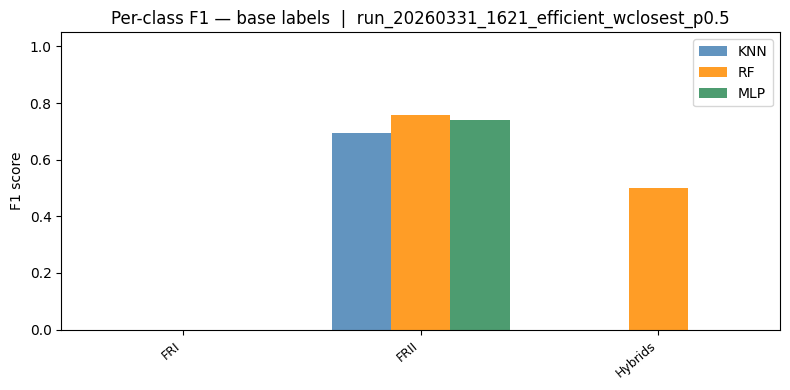

In [ ]:
classifiers = {
    'Dummy':  results_dummy,
    'LR':     results_lr,
    'KNN':    results_knn,
    'RF':     results_rf,
    'MLP':    results_mlp,
}

x       = np.arange(n_classes)
width   = 0.15
offsets = np.linspace(-2*width, 2*width, len(classifiers))
colors  = ['grey', 'mediumpurple', 'steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(max(10, n_classes * 1.4), 4))
for (name, res), off, col in zip(classifiers.items(), offsets, colors):
    ax.bar(x + off, res['f1_per_class'], width, label=name, color=col, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1.05)
ax.set_title(f'Per-class F1 — {LABEL_SET} labels  |  {run_name}')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(f"\n{'Classifier':<22} {'Macro F1':>10} {'Macro AUC':>10} {'Accuracy':>10}")
print('-' * 56)
for name, res in classifiers.items():
    print(f"{name:<22} {res['f1_macro']:>10.4f} "
          f"{res['auc_macro']:>10.4f} {res['accuracy']:>10.4f}")